# Conversion Rate  : first models 🏆🏆

In [7]:
# Chargement des librairies

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, confusion_matrix
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from sklearn.metrics import ConfusionMatrixDisplay, classification_report


#setting Jedha color palette as default
pio.templates["jedha"] = go.layout.Template(
  layout_colorway=["#4B9AC7", "#4BE8E0", "#9DD4F3", "#97FBF6", "#2A7FAF", "#23B1AB", "#0E3449", "#015955"]
)
pio.templates.default = "jedha"
#pio.renderers.default = "svg" # to be replaced by "iframe" if working on JULIE
from IPython.display import display

In [8]:
df = pd.read_csv('conversion_data_train.csv')

## Preprocessing

In [9]:
# Définition de la cible et des features

df = pd.read_csv('conversion_data_train.csv')

target_variable = "converted"
X = df.drop(target_variable, axis=1)
Y = df[target_variable]

# Détection des colonnes numériques et catégorielles
numeric_features = [col for col in X.columns if X[col].dtype in ['int64', 'float64']]
categorical_features = [col for col in X.columns if col not in numeric_features]

# Split train/test
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=0)

# Prétraitement des données
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(drop="first")
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

# Transformation des données
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

# Encodage des labels
encoder = LabelEncoder()
Y_train = encoder.fit_transform(Y_train)
Y_test = encoder.transform(Y_test)

## Modèle : Regression Logistique. Score 4 chiffres après la virgule sur Test Set

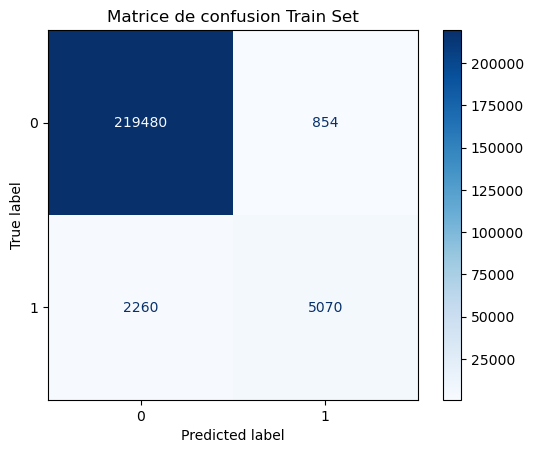

Métriques pour le train set :
              precision    recall  f1-score   support

           0       0.99      1.00      0.99    220334
           1       0.86      0.69      0.77      7330

    accuracy                           0.99    227664
   macro avg       0.92      0.84      0.88    227664
weighted avg       0.99      0.99      0.99    227664



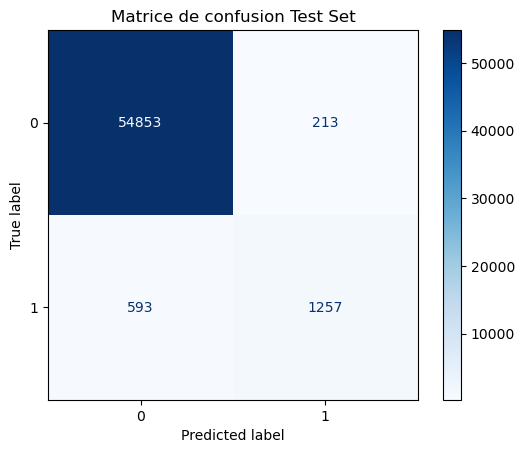

Métriques pour le test set :
              precision    recall  f1-score   support

           0     0.9893    0.9961    0.9927     55066
           1     0.8551    0.6795    0.7572      1850

    accuracy                         0.9858     56916
   macro avg     0.9222    0.8378    0.8750     56916
weighted avg     0.9849    0.9858    0.9851     56916



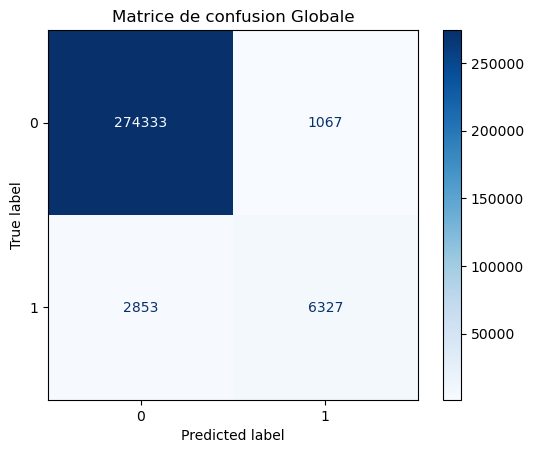

Métriques globales :
              precision    recall  f1-score   support

           0       0.99      1.00      0.99    275400
           1       0.86      0.69      0.76      9180

    accuracy                           0.99    284580
   macro avg       0.92      0.84      0.88    284580
weighted avg       0.99      0.99      0.99    284580



In [7]:
# Construire et entraîner le modèle de régression logistique
logistic_model = LogisticRegression()
logistic_model.fit(X_train, Y_train)

# Prédictions
Y_train_pred = logistic_model.predict(X_train)
Y_test_pred = logistic_model.predict(X_test)

# Matrice de confusion pour le train set
cm_train = confusion_matrix(Y_train, Y_train_pred)
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train)
disp_train.plot(cmap='Blues')
plt.title("Matrice de confusion Train Set")
plt.show()

# Métriques pour le train set
print("Métriques pour le train set :")
print(classification_report(Y_train, Y_train_pred))

# Matrice de confusion pour le test set
cm_test = confusion_matrix(Y_test, Y_test_pred)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test)
disp_test.plot(cmap='Blues')
plt.title("Matrice de confusion Test Set")
plt.show()

# Métriques pour le test set
print("Métriques pour le test set :")
print(classification_report(Y_test, Y_test_pred, digits=4))

# Matrice de confusion globale (train + test)
Y_global = np.concatenate((Y_train, Y_test))
Y_global_pred = np.concatenate((Y_train_pred, Y_test_pred))
cm_global = confusion_matrix(Y_global, Y_global_pred)
disp_global = ConfusionMatrixDisplay(confusion_matrix=cm_global)
disp_global.plot(cmap='Blues')
plt.title("Matrice de confusion Globale")
plt.show()

# Métriques globales
print("Métriques globales :")
print(classification_report(Y_global, Y_global_pred))

## Modèle Random Forest

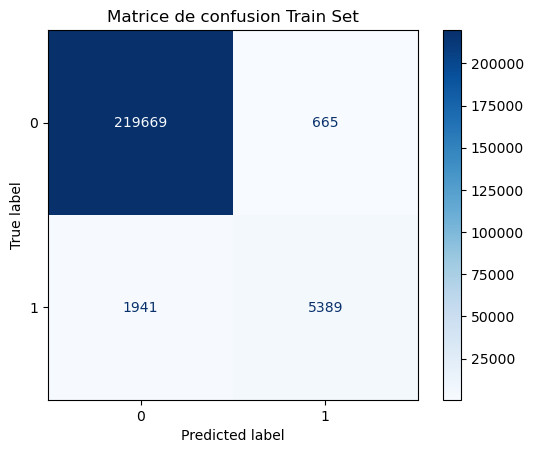

Métriques pour le train set :
              precision    recall  f1-score   support

           0       0.99      1.00      0.99    220334
           1       0.89      0.74      0.81      7330

    accuracy                           0.99    227664
   macro avg       0.94      0.87      0.90    227664
weighted avg       0.99      0.99      0.99    227664



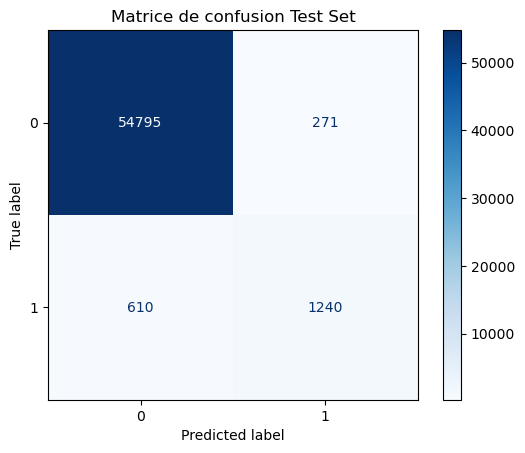

Métriques pour le test set :
              precision    recall  f1-score   support

           0     0.9890    0.9951    0.9920     55066
           1     0.8206    0.6703    0.7379      1850

    accuracy                         0.9845     56916
   macro avg     0.9048    0.8327    0.8650     56916
weighted avg     0.9835    0.9845    0.9838     56916



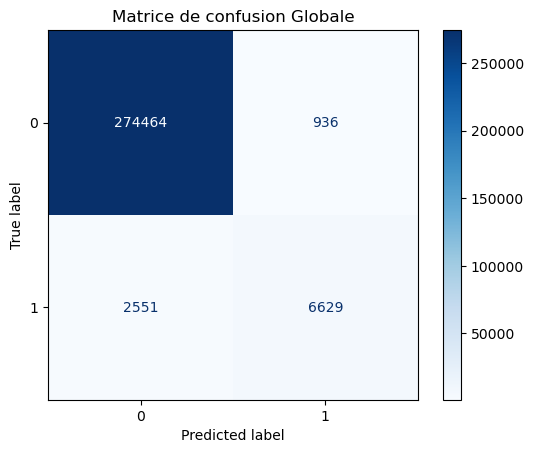

Métriques globales :
              precision    recall  f1-score   support

           0       0.99      1.00      0.99    275400
           1       0.88      0.72      0.79      9180

    accuracy                           0.99    284580
   macro avg       0.93      0.86      0.89    284580
weighted avg       0.99      0.99      0.99    284580



In [9]:
# Construire et entraîner le modèle de Random Forest
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(n_estimators=100, random_state=42)
random_forest_model.fit(X_train, Y_train)

# Prédictions
Y_train_pred = random_forest_model.predict(X_train)
Y_test_pred = random_forest_model.predict(X_test)

# Matrice de confusion pour le train set
cm_train = confusion_matrix(Y_train, Y_train_pred)
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train)
disp_train.plot(cmap='Blues')
plt.title("Matrice de confusion Train Set")
plt.show()

# Métriques pour le train set
print("Métriques pour le train set :")
print(classification_report(Y_train, Y_train_pred))

# Matrice de confusion pour le test set
cm_test = confusion_matrix(Y_test, Y_test_pred)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test)
disp_test.plot(cmap='Blues')
plt.title("Matrice de confusion Test Set")
plt.show()

# Métriques pour le test set
print("Métriques pour le test set :")
print(classification_report(Y_test, Y_test_pred, digits=4))

# Matrice de confusion globale (train + test)
Y_global = np.concatenate((Y_train, Y_test))
Y_global_pred = np.concatenate((Y_train_pred, Y_test_pred))
cm_global = confusion_matrix(Y_global, Y_global_pred)
disp_global = ConfusionMatrixDisplay(confusion_matrix=cm_global)
disp_global.plot(cmap='Blues')
plt.title("Matrice de confusion Globale")
plt.show()

# Métriques globales
print("Métriques globales :")
print(classification_report(Y_global, Y_global_pred))

## Modèle XGBOOST

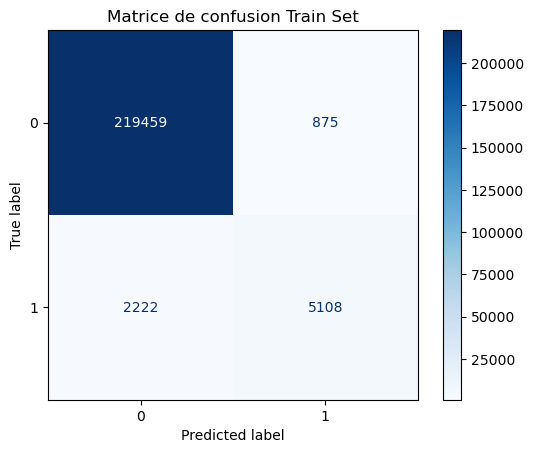

Métriques pour le train set :
              precision    recall  f1-score   support

           0       0.99      1.00      0.99    220334
           1       0.85      0.70      0.77      7330

    accuracy                           0.99    227664
   macro avg       0.92      0.85      0.88    227664
weighted avg       0.99      0.99      0.99    227664



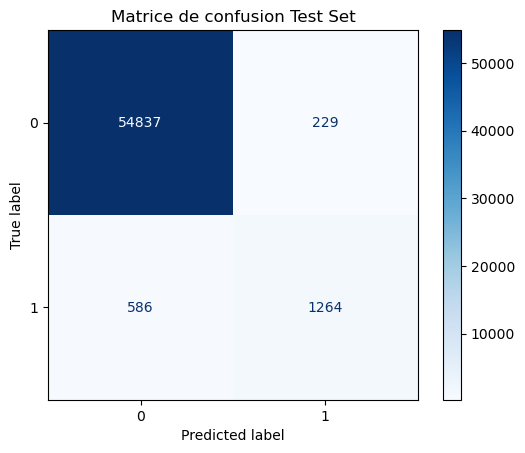

Métriques pour le test set :
              precision    recall  f1-score   support

           0     0.9894    0.9958    0.9926     55066
           1     0.8466    0.6832    0.7562      1850

    accuracy                         0.9857     56916
   macro avg     0.9180    0.8395    0.8744     56916
weighted avg     0.9848    0.9857    0.9849     56916



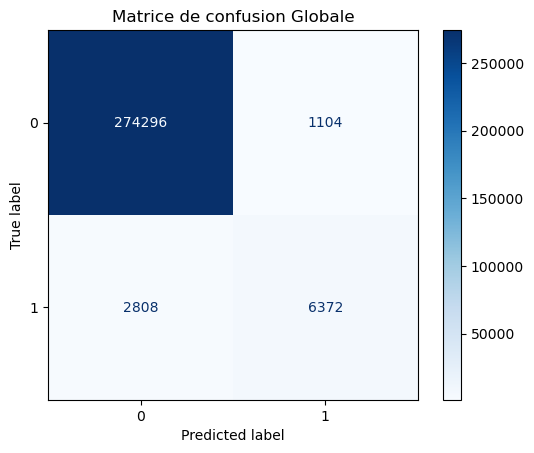

Métriques globales :
              precision    recall  f1-score   support

           0       0.99      1.00      0.99    275400
           1       0.85      0.69      0.77      9180

    accuracy                           0.99    284580
   macro avg       0.92      0.85      0.88    284580
weighted avg       0.99      0.99      0.99    284580



In [11]:
# Construire et entraîner le modèle XGBoost
import xgboost as xgb

xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    max_depth=5,
    learning_rate=0.1,
    n_estimators=100,
    random_state=0
)
xgb_model.fit(X_train, Y_train)

# Prédictions
Y_train_pred = xgb_model.predict(X_train)
Y_test_pred = xgb_model.predict(X_test)

# Matrice de confusion pour le train set
cm_train = confusion_matrix(Y_train, Y_train_pred)
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train)
disp_train.plot(cmap='Blues')
plt.title("Matrice de confusion Train Set")
plt.show()

# Métriques pour le train set
print("Métriques pour le train set :")
print(classification_report(Y_train, Y_train_pred))

# Matrice de confusion pour le test set
cm_test = confusion_matrix(Y_test, Y_test_pred)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test)
disp_test.plot(cmap='Blues')
plt.title("Matrice de confusion Test Set")
plt.show()

# Métriques pour le test set
print("Métriques pour le test set :")
print(classification_report(Y_test, Y_test_pred, digits=4))

# Matrice de confusion globale (train + test)
Y_global = np.concatenate((Y_train, Y_test))
Y_global_pred = np.concatenate((Y_train_pred, Y_test_pred))
cm_global = confusion_matrix(Y_global, Y_global_pred)
disp_global = ConfusionMatrixDisplay(confusion_matrix=cm_global)
disp_global.plot(cmap='Blues')
plt.title("Matrice de confusion Globale")
plt.show()

# Métriques globales
print("Métriques globales :")
print(classification_report(Y_global, Y_global_pred))

## Performance assessment

In [5]:
# Chargement des librairies communes aux modèles

import optuna
from sklearn.model_selection import GridSearchCV
from tqdm import tqdm

## XGBOOST et GridSearchCV


🔍 Lancement de GridSearchCV...


[I 2025-09-05 23:04:54,930] A new study created in memory with name: no-name-431e4659-fdfd-446f-853b-afd196192551


✅ GridSearch terminé!
Meilleurs paramètres: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}

🎯 Début de l'optimisation Optuna...


Optuna Trials: 100%|██████████| 30/30 [01:00<00:00,  2.01s/it]


✅ Optuna terminé!
Meilleurs paramètres Optuna: {'n_estimators': 250, 'max_depth': 4, 'learning_rate': 0.1365870255293576, 'subsample': 0.793473966667406, 'colsample_bytree': 0.6075861141110814, 'gamma': 1.4518380279293648, 'reg_alpha': 0.32590722231786184, 'reg_lambda': 0.772500509315615, 'min_child_weight': 10}

📊 Évaluation du modèle final

🔹 Train Set
Accuracy: 0.9863
F1 macro: 0.8794
F1 weighted: 0.9856
              precision    recall  f1-score   support

           0     0.9899    0.9961    0.9930    220334
           1     0.8547    0.6936    0.7658      7330

    accuracy                         0.9863    227664
   macro avg     0.9223    0.8448    0.8794    227664
weighted avg     0.9855    0.9863    0.9856    227664



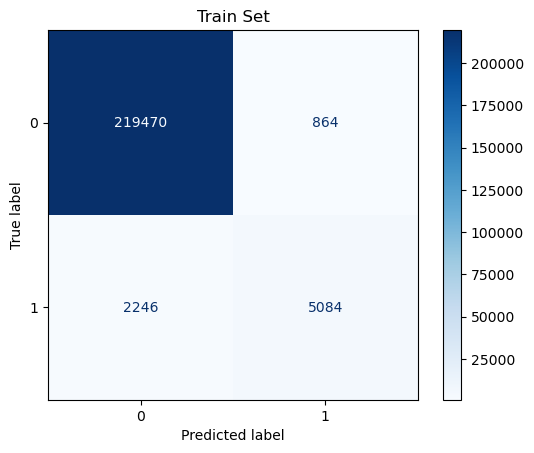


🔹 Test Set
Accuracy: 0.9859
F1 macro: 0.8763
F1 weighted: 0.9852
              precision    recall  f1-score   support

           0     0.9895    0.9960    0.9928     55066
           1     0.8532    0.6849    0.7598      1850

    accuracy                         0.9859     56916
   macro avg     0.9213    0.8405    0.8763     56916
weighted avg     0.9851    0.9859    0.9852     56916



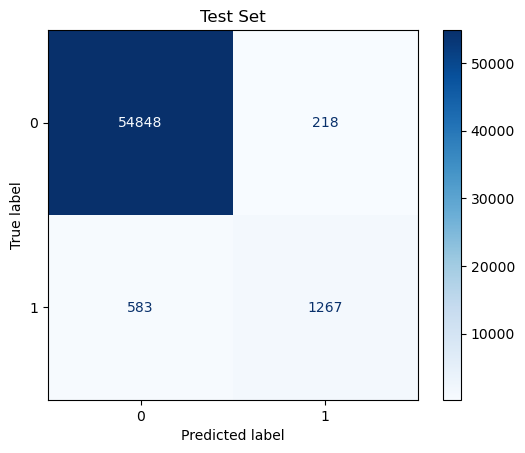


🔹 Global Set
Accuracy: 0.9863
F1 macro: 0.8788
F1 weighted: 0.9856
              precision    recall  f1-score   support

           0     0.9898    0.9961    0.9929    275400
           1     0.8544    0.6918    0.7646      9180

    accuracy                         0.9863    284580
   macro avg     0.9221    0.8440    0.8788    284580
weighted avg     0.9854    0.9863    0.9856    284580



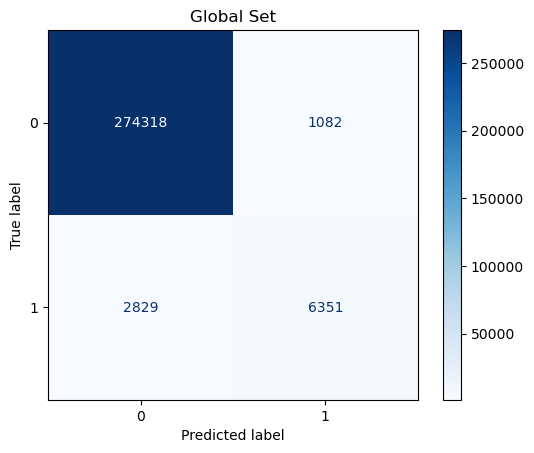


🎯 Résumé F1:
F1 Score Train Set : 0.8794
F1 Score Test Set  : 0.8763
F1 Score Global Set: 0.8788


In [12]:
import xgboost as xgb
from sklearn.model_selection import cross_val_score

# -----------------------------
# Étape 1 : GridSearchCV simple
# -----------------------------
xgb_model = xgb.XGBClassifier(
    eval_metric="logloss",
    random_state=42
)
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5],
    "learning_rate": [0.1, 0.2]
}
print("\n🔍 Lancement de GridSearchCV...")
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=3,
    scoring="f1_macro",
    verbose=0,
    n_jobs=-1
)
grid_search.fit(X_train, Y_train)
print("✅ GridSearch terminé!")
print("Meilleurs paramètres:", grid_search.best_params_)

# -----------------------------
# Étape 2 : Optuna (avec cross_val_score pour éviter le leakage)
# -----------------------------
def objective(trial):
    param = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 300, step=50),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.05, 0.3),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 2),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 2),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 2),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "eval_metric": "logloss",
        "random_state": 42,
    }
    model = xgb.XGBClassifier(**param)
    score = cross_val_score(model, X_train, Y_train, cv=3, scoring="f1_macro").mean()
    return score

print("\n🎯 Début de l'optimisation Optuna...")
study = optuna.create_study(direction="maximize")
with tqdm(total=30, desc="Optuna Trials") as pbar:
    def tqdm_callback(study, trial):
        pbar.update(1)
    study.optimize(objective, n_trials=30, callbacks=[tqdm_callback])
print("✅ Optuna terminé!")
print("Meilleurs paramètres Optuna:", study.best_params)

# -----------------------------
# Étape 3 : Modèle final avec les meilleurs paramètres
# -----------------------------
final_params = dict(study.best_params)
final_params.update({"eval_metric": "logloss", "random_state": 42})
final_model = xgb.XGBClassifier(**final_params)
final_model.fit(X_train, Y_train)

# -----------------------------
# Étape 4 : Évaluation
# -----------------------------
print("\n📊 Évaluation du modèle final")
y_train_pred = final_model.predict(X_train)
y_test_pred = final_model.predict(X_test)
y_global_true = np.concatenate([Y_train, Y_test])
y_global_pred = np.concatenate([y_train_pred, y_test_pred])

def display_metrics(y_true, y_pred, title):
    print(f"\n🔹 {title}")
    print("Accuracy: {:.4f}".format(np.mean(y_true == y_pred)))
    print("F1 macro: {:.4f}".format(f1_score(y_true, y_pred, average="macro")))
    print("F1 weighted: {:.4f}".format(f1_score(y_true, y_pred, average="weighted")))
    print(classification_report(y_true, y_pred, digits=4))
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues")
    plt.title(title)
    plt.show()

# Résultats
display_metrics(Y_train, y_train_pred, "Train Set")
display_metrics(Y_test, y_test_pred, "Test Set")
display_metrics(y_global_true, y_global_pred, "Global Set")

# Résumé F1
print("\n🎯 Résumé F1:")
print(f"F1 Score Train Set : {f1_score(Y_train, y_train_pred, average='macro'):.4f}")
print(f"F1 Score Test Set  : {f1_score(Y_test, y_test_pred, average='macro'):.4f}")
print(f"F1 Score Global Set: {f1_score(y_global_true, y_global_pred, average='macro'):.4f}")




## GradientBoostingClassifier


🔍 Lancement de GridSearchCV...


[I 2025-09-05 23:12:35,163] A new study created in memory with name: no-name-2b46b2c8-7a18-4d6e-acea-81757e8894c8


✅ GridSearch terminé!
Meilleurs paramètres: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}

🎯 Début de l'optimisation Optuna...


Optuna Trials: 100%|██████████| 30/30 [20:14<00:00, 40.47s/it]


✅ Optuna terminé!
Meilleurs paramètres Optuna: {'n_estimators': 250, 'max_depth': 4, 'learning_rate': 0.05121696664552193, 'min_samples_split': 17, 'min_samples_leaf': 7, 'max_features': 'log2', 'subsample': 0.6966915924288093}

📊 Évaluation du modèle final

🔹 Train Set
Accuracy: 0.9864
F1 macro: 0.8807
F1 weighted: 0.9858
              precision    recall  f1-score   support

           0     0.9901    0.9959    0.9930    220334
           1     0.8506    0.7005    0.7683      7330

    accuracy                         0.9864    227664
   macro avg     0.9203    0.8482    0.8807    227664
weighted avg     0.9856    0.9864    0.9858    227664



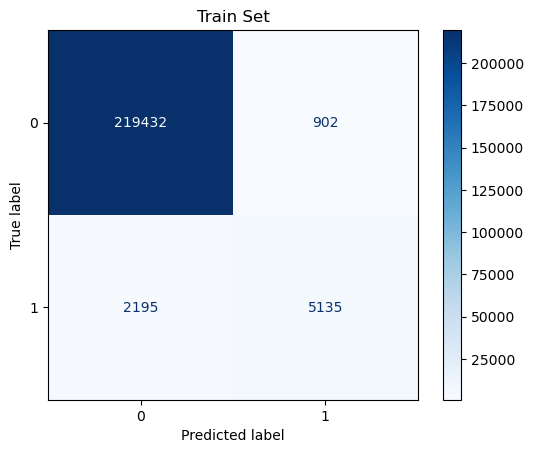


🔹 Test Set
Accuracy: 0.9857
F1 macro: 0.8752
F1 weighted: 0.9850
              precision    recall  f1-score   support

           0     0.9896    0.9957    0.9926     55066
           1     0.8430    0.6881    0.7577      1850

    accuracy                         0.9857     56916
   macro avg     0.9163    0.8419    0.8752     56916
weighted avg     0.9848    0.9857    0.9850     56916



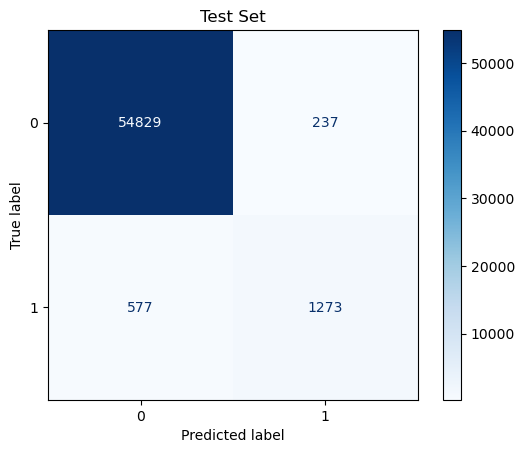


🔹 Global Set
Accuracy: 0.9863
F1 macro: 0.8796
F1 weighted: 0.9856
              precision    recall  f1-score   support

           0     0.9900    0.9959    0.9929    275400
           1     0.8491    0.6980    0.7662      9180

    accuracy                         0.9863    284580
   macro avg     0.9195    0.8470    0.8796    284580
weighted avg     0.9854    0.9863    0.9856    284580



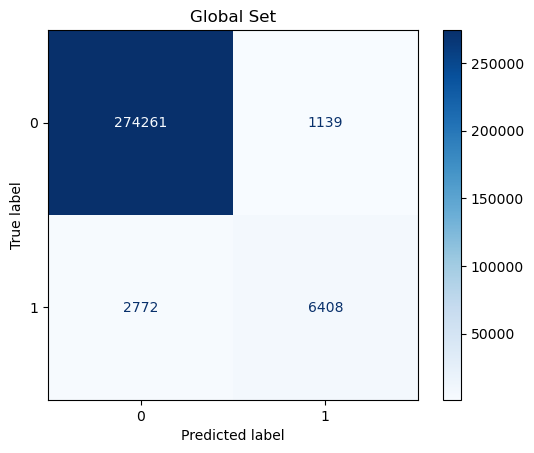


🎯 Résumé F1:
F1 Score Train Set : 0.8807
F1 Score Test Set  : 0.8752
F1 Score Global Set: 0.8796


In [13]:
from sklearn.ensemble import GradientBoostingClassifier

# -----------------------------
# Étape 1 : GridSearchCV simple
# -----------------------------
gb_model = GradientBoostingClassifier(random_state=42)
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5],
    "learning_rate": [0.1, 0.2]
}
print("\n🔍 Lancement de GridSearchCV...")
grid_search = GridSearchCV(
    estimator=gb_model,
    param_grid=param_grid,
    cv=3,
    scoring="f1_macro",
    verbose=0,
    n_jobs=-1
)
grid_search.fit(X_train, Y_train)
print("✅ GridSearch terminé!")
print("Meilleurs paramètres:", grid_search.best_params_)

# -----------------------------
# Étape 2 : Optuna (avec cross_val_score pour éviter le leakage)
# -----------------------------
def objective(trial):
    param = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 300, step=50),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.05, 0.3),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "random_state": 42,
    }
    model = GradientBoostingClassifier(**param)
    score = cross_val_score(model, X_train, Y_train, cv=3, scoring="f1_macro").mean()
    return score

print("\n🎯 Début de l'optimisation Optuna...")
study = optuna.create_study(direction="maximize")
with tqdm(total=30, desc="Optuna Trials") as pbar:
    def tqdm_callback(study, trial):
        pbar.update(1)
    study.optimize(objective, n_trials=30, callbacks=[tqdm_callback])
print("✅ Optuna terminé!")
print("Meilleurs paramètres Optuna:", study.best_params)

# -----------------------------
# Étape 3 : Modèle final avec les meilleurs paramètres
# -----------------------------
final_params = dict(study.best_params)
final_params.update({"random_state": 42})
final_model = GradientBoostingClassifier(**final_params)
final_model.fit(X_train, Y_train)

# -----------------------------
# Étape 4 : Évaluation
# -----------------------------
print("\n📊 Évaluation du modèle final")
y_train_pred = final_model.predict(X_train)
y_test_pred = final_model.predict(X_test)
y_global_true = np.concatenate([Y_train, Y_test])
y_global_pred = np.concatenate([y_train_pred, y_test_pred])

def display_metrics(y_true, y_pred, title):
    print(f"\n🔹 {title}")
    print("Accuracy: {:.4f}".format(np.mean(y_true == y_pred)))
    print("F1 macro: {:.4f}".format(f1_score(y_true, y_pred, average="macro")))
    print("F1 weighted: {:.4f}".format(f1_score(y_true, y_pred, average="weighted")))
    print(classification_report(y_true, y_pred, digits=4))
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues")
    plt.title(title)
    plt.show()

# Résultats
display_metrics(Y_train, y_train_pred, "Train Set")
display_metrics(Y_test, y_test_pred, "Test Set")
display_metrics(y_global_true, y_global_pred, "Global Set")

# Résumé F1
print("\n🎯 Résumé F1:")
print(f"F1 Score Train Set : {f1_score(Y_train, y_train_pred, average='macro'):.4f}")
print(f"F1 Score Test Set  : {f1_score(Y_test, y_test_pred, average='macro'):.4f}")
print(f"F1 Score Global Set: {f1_score(y_global_true, y_global_pred, average='macro'):.4f}")


## Test XGBOOST GridSearch Versus Optuna


🚀 XGBoost GridSearch avec barre de progression tqdm
Paramètres XGBoost à tester: {'n_estimators': [100, 200, 300], 'max_depth': [3, 4, 6], 'learning_rate': [0.1, 0.2, 0.3], 'subsample': [0.8, 0.9, 1.0]}
Total de combinaisons: 81
🔍 Démarrage de XGBoost GridSearch avec tqdm...


🔍 XGBoost GridSearch:   0%|          | 0/81 [00:00<?, ?it/s]

[I 2025-08-03 16:11:20,498] A new study created in memory with name: no-name-57e2dff6-243b-4b37-b856-a8a928d04b10



✅ XGBoost GridSearch terminé!
Meilleurs paramètres: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}
Meilleur score CV: 0.9862
Score sur train: 0.9864
Score sur test: 0.9857

🔗 Utilisation des résultats GridSearch pour optimiser Optuna...
Meilleurs paramètres GridSearch: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}

🎯 Optuna avec barre de progression
🎯 Optuna avec recherche guidée par GridSearch
🎯 Exploration fine autour de: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}
➕ Ajout de nouveaux paramètres XGBoost: colsample_bytree, gamma, reg_alpha, reg_lambda, min_child_weight


[I 2025-08-03 16:11:21,834] Trial 0 finished with value: 0.875366568914956 and parameters: {'n_estimators': 350, 'max_depth': 4, 'learning_rate': 0.2734486289100349, 'subsample': 0.9094353913317005, 'colsample_bytree': 0.9706602246033825, 'gamma': 0.31151734129550857, 'reg_alpha': 0.6193804049756597, 'reg_lambda': 1.5007033887103838, 'min_child_weight': 2}. Best is trial 0 with value: 0.875366568914956.


🔍 XGBoost Optuna Optimization:   0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-08-03 16:11:23,385] Trial 1 finished with value: 0.8756022446239508 and parameters: {'n_estimators': 400, 'max_depth': 4, 'learning_rate': 0.0746470328532313, 'subsample': 0.8741967103586957, 'colsample_bytree': 0.769746129242193, 'gamma': 1.149801668780492, 'reg_alpha': 0.1489189976397871, 'reg_lambda': 0.9640969234106358, 'min_child_weight': 10}. Best is trial 1 with value: 0.8756022446239508.
[I 2025-08-03 16:11:24,338] Trial 2 finished with value: 0.874139287341755 and parameters: {'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.1593176531052521, 'subsample': 0.8677512388316663, 'colsample_bytree': 0.9944258967348063, 'gamma': 0.7450338650157862, 'reg_alpha': 1.12761759300942, 'reg_lambda': 0.23620286020729409, 'min_child_weight': 3}. Best is trial 1 with value: 0.8756022446239508.
[I 2025-08-03 16:11:24,967] Trial 3 finished with value: 0.8760077281563554 and parameters: {'n_estimators': 150, 'max_depth': 4, 'learning_rate': 0.08581854644252251, 'subsample': 0.8571


✅ Optimisation hybride XGBoost terminée!
Amélioration: 0.8780 vs 0.9862 (GridSearch)
Gain de performance: -0.1082 (-10.82%)

🔧 Paramètres finaux XGBoost optimisés:
  • n_estimators: 150 (GridSearch: 200)
  • max_depth: 6 (GridSearch: 3)
  • learning_rate: 0.14432041860571707 (GridSearch: 0.1)
  • subsample: 0.9162065362170148 (GridSearch: 1.0)
  • colsample_bytree: 0.9750550190930083 (nouveau paramètre)
  • gamma: 0.49525936500122236 (nouveau paramètre)
  • reg_alpha: 0.8215791621406572 (nouveau paramètre)
  • reg_lambda: 1.6851300747750177 (nouveau paramètre)
  • min_child_weight: 10 (nouveau paramètre)

🎯 F1 SCORES SUR LE TEST SET:
GridSearch seul:     0.8744
Approche hybride:    0.8779

🎯 ACCURACY SUR LE TEST SET:
GridSearch seul:     0.9857
Approche hybride:    0.9860

📊 MATRICES DE CONFUSION - APPROCHE HYBRIDE XGBOOST


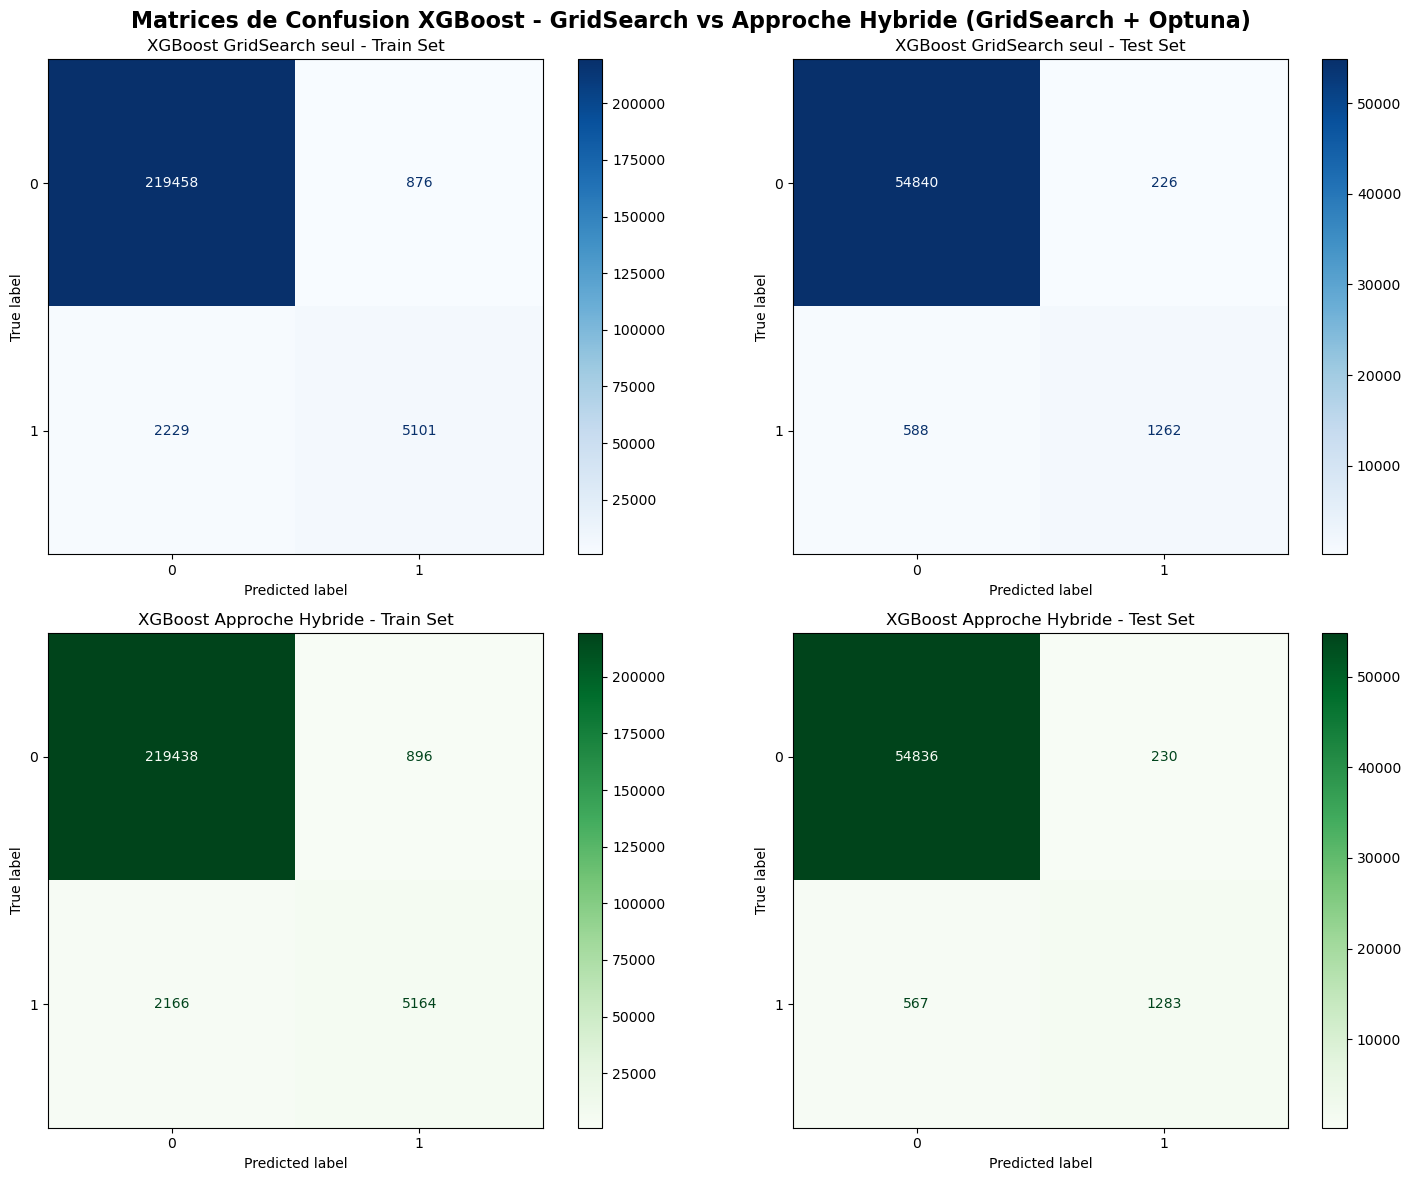

📈 MÉTRIQUES DÉTAILLÉES XGBOOST

🔹 XGBOOST GRIDSEARCH SEUL - TRAIN SET:
Accuracy: 0.9864
F1 Score (macro): 0.8798
F1 Score (weighted): 0.9857

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99    220334
           1       0.85      0.70      0.77      7330

    accuracy                           0.99    227664
   macro avg       0.92      0.85      0.88    227664
weighted avg       0.99      0.99      0.99    227664


🔹 XGBOOST GRIDSEARCH SEUL - TEST SET:
Accuracy: 0.9857
F1 Score (macro): 0.8744
F1 Score (weighted): 0.9849

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     55066
           1       0.85      0.68      0.76      1850

    accuracy                           0.99     56916
   macro avg       0.92      0.84      0.87     56916
weighted avg       0.98      0.99      0.98     56916


🔸 XGBOOST APPROCHE HYBRIDE - TRAIN SET:
Accurac

In [12]:
import optuna
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, ParameterGrid
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score, classification_report
from tqdm.notebook import tqdm
import time
import numpy as np
from sklearn.base import clone

# Supposons que X_train, X_test, Y_train, Y_test soient déjà définis

# SOLUTION: Wrapper pour GridSearchCV avec tqdm
class TqdmGridSearchCV:
    def __init__(self, estimator, param_grid, cv=5, scoring=None, n_jobs=1):
        self.estimator = estimator
        self.param_grid = param_grid
        self.cv = cv
        self.scoring = scoring
        self.n_jobs = n_jobs
        self.best_params_ = None
        self.best_score_ = None
        self.best_estimator_ = None
        self.cv_results_ = {}
        
    def fit(self, X, y):
        # Créer la grille de paramètres
        param_list = list(ParameterGrid(self.param_grid))
        
        results = []
        best_score = -np.inf
        best_params = None
        best_estimator = None
        
        # Barre de progression avec tqdm
        with tqdm(total=len(param_list), desc="🔍 XGBoost GridSearch") as pbar:
            for i, params in enumerate(param_list):
                # Cloner l'estimateur et définir les paramètres
                estimator = clone(self.estimator)
                estimator.set_params(**params)
                
                # Validation croisée
                scores = cross_val_score(estimator, X, y, cv=self.cv, scoring=self.scoring, n_jobs=1)
                mean_score = scores.mean()
                std_score = scores.std()
                
                # Stocker les résultats
                results.append({
                    'params': params,
                    'mean_test_score': mean_score,
                    'std_test_score': std_score,
                    'rank_test_score': 0  # Sera calculé après
                })
                
                # Mettre à jour le meilleur
                if mean_score > best_score:
                    best_score = mean_score
                    best_params = params
                    # Entraîner le meilleur estimateur sur toutes les données
                    best_estimator = clone(self.estimator)
                    best_estimator.set_params(**params)
                    best_estimator.fit(X, y)
                
                # Mettre à jour la barre de progression
                pbar.set_postfix({
                    'Current': f'{mean_score:.4f}',
                    'Best': f'{best_score:.4f}',
                    'Params': f'{i+1}/{len(param_list)}'
                })
                pbar.update(1)
        
        # Calculer les rangs
        results.sort(key=lambda x: x['mean_test_score'], reverse=True)
        for i, result in enumerate(results):
            result['rank_test_score'] = i + 1
        
        # Stocker les résultats
        self.best_score_ = best_score
        self.best_params_ = best_params
        self.best_estimator_ = best_estimator
        self.cv_results_ = {
            'params': [r['params'] for r in results],
            'mean_test_score': [r['mean_test_score'] for r in results],
            'std_test_score': [r['std_test_score'] for r in results],
            'rank_test_score': [r['rank_test_score'] for r in results]
        }
        
        return self
    
    def predict(self, X):
        return self.best_estimator_.predict(X)
    
    def score(self, X, y):
        return self.best_estimator_.score(X, y)

# Utilisation du wrapper avec XGBoost
print("\n" + "="*60)
print("🚀 XGBoost GridSearch avec barre de progression tqdm")
print("="*60)

# Définir le modèle XGBoost
model = xgb.XGBClassifier(
    random_state=42,
    eval_metric='logloss',  # Évite les warnings
    verbosity=0  # Réduit les sorties
)

# Paramètres spécifiques à XGBoost pour GridSearch
params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 4, 6],
    "learning_rate": [0.1, 0.2, 0.3],
    "subsample": [0.8, 0.9, 1.0],
}

print(f"Paramètres XGBoost à tester: {params}")
total_combinations = np.prod([len(v) for v in params.values()])
print(f"Total de combinaisons: {total_combinations}")

# Utiliser notre wrapper avec tqdm
tqdm_gridsearch = TqdmGridSearchCV(
    estimator=model,
    param_grid=params,
    cv=3,
    scoring='accuracy'
)

print("🔍 Démarrage de XGBoost GridSearch avec tqdm...")
tqdm_gridsearch.fit(X_train, Y_train)

print("\n✅ XGBoost GridSearch terminé!")
print(f"Meilleurs paramètres: {tqdm_gridsearch.best_params_}")
print(f"Meilleur score CV: {tqdm_gridsearch.best_score_:.4f}")
print(f"Score sur train: {tqdm_gridsearch.score(X_train, Y_train):.4f}")
print(f"Score sur test: {tqdm_gridsearch.score(X_test, Y_test):.4f}")

# Utilisation des résultats de GridSearch pour orienter Optuna
print(f"\n🔗 Utilisation des résultats GridSearch pour optimiser Optuna...")
print(f"Meilleurs paramètres GridSearch: {tqdm_gridsearch.best_params_}")

# Définir des ranges pour Optuna basés sur GridSearch
best_grid_params = tqdm_gridsearch.best_params_

# Optuna avec tqdm (votre partie originale)
print("\n" + "="*60)
print("🎯 Optuna avec barre de progression")
print("="*60)

class OptunaTqdmCallback:
    def __init__(self, n_trials):
        self.n_trials = n_trials
        self.pbar = None
        
    def __call__(self, study, trial):
        if self.pbar is None:
            self.pbar = tqdm(total=self.n_trials, desc="🔍 XGBoost Optuna Optimization")
        
        self.pbar.update(1)
        best_value = study.best_value if study.best_value else 0
        self.pbar.set_postfix({
            'Current F1': f'{trial.value:.4f}',
            'Best F1': f'{best_value:.4f}',
        })
        
        if trial.number + 1 >= self.n_trials:
            self.pbar.close()

def objective(trial):
    # Utiliser les résultats de GridSearch pour définir des ranges intelligents
    # autour des meilleurs paramètres trouvés
    
    # Définir les ranges basés sur les meilleurs paramètres GridSearch
    best_n_estimators = best_grid_params['n_estimators']
    best_max_depth = best_grid_params['max_depth']
    best_learning_rate = best_grid_params['learning_rate']
    best_subsample = best_grid_params['subsample']
    
    param = {
        # Exploration autour des meilleurs valeurs GridSearch avec plus de granularité
        'n_estimators': trial.suggest_int('n_estimators', 
                                        max(50, best_n_estimators - 100), 
                                        best_n_estimators + 200, 
                                        step=50),
        'max_depth': trial.suggest_int('max_depth', 
                                     max(2, best_max_depth - 1), 
                                     min(10, best_max_depth + 3)),
        'learning_rate': trial.suggest_float('learning_rate', 
                                           max(0.01, best_learning_rate - 0.1), 
                                           min(0.5, best_learning_rate + 0.2)),
        'subsample': trial.suggest_float('subsample', 
                                       max(0.5, best_subsample - 0.2), 
                                       min(1.0, best_subsample + 0.1)),
        # Ajouter des paramètres spécifiques XGBoost que GridSearch n'a pas explorés
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 2),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 2),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 2),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        # Paramètres fixes
        'random_state': 42,
        'eval_metric': 'logloss',
        'verbosity': 0
    }
    
    model = xgb.XGBClassifier(**param)
    model.fit(X_train, Y_train)
    predictions = model.predict(X_test)
    f1 = f1_score(Y_test, predictions, average='macro')
    return f1

# Optimisation Optuna guidée par GridSearch
print("🎯 Optuna avec recherche guidée par GridSearch")
print("="*60)
print(f"🎯 Exploration fine autour de: {best_grid_params}")
print(f"➕ Ajout de nouveaux paramètres XGBoost: colsample_bytree, gamma, reg_alpha, reg_lambda, min_child_weight")

n_trials = 50  # Plus d'essais pour l'optimisation fine
study = optuna.create_study(direction='maximize')
callback = OptunaTqdmCallback(n_trials)
study.optimize(objective, n_trials=n_trials, callbacks=[callback])

print(f"\n✅ Optimisation hybride XGBoost terminée!")
print(f"Amélioration: {study.best_value:.4f} vs {tqdm_gridsearch.best_score_:.4f} (GridSearch)")
improvement = study.best_value - tqdm_gridsearch.best_score_
print(f"Gain de performance: {improvement:.4f} ({improvement*100:.2f}%)")

print(f"\n🔧 Paramètres finaux XGBoost optimisés:")
for key, value in study.best_params.items():
    if key in best_grid_params:
        print(f"  • {key}: {value} (GridSearch: {best_grid_params[key]})")
    else:
        print(f"  • {key}: {value} (nouveau paramètre)")

# Modèle final combinant les deux approches
final_model = xgb.XGBClassifier(**study.best_params)
final_model.fit(X_train, Y_train)

y_pred_grid = tqdm_gridsearch.predict(X_test)
y_pred_final = final_model.predict(X_test)

print(f"\n🎯 F1 SCORES SUR LE TEST SET:")
print(f"GridSearch seul:     {f1_score(Y_test, y_pred_grid, average='macro'):.4f}")
print(f"Approche hybride:    {f1_score(Y_test, y_pred_final, average='macro'):.4f}")

print(f"\n🎯 ACCURACY SUR LE TEST SET:")
print(f"GridSearch seul:     {tqdm_gridsearch.score(X_test, Y_test):.4f}")
print(f"Approche hybride:    {final_model.score(X_test, Y_test):.4f}")

# Matrices de confusion et métriques complètes
print("\n" + "="*60)
print("📊 MATRICES DE CONFUSION - APPROCHE HYBRIDE XGBOOST")
print("="*60)

# Prédictions pour les deux approches
y_train_pred_grid = tqdm_gridsearch.predict(X_train)
y_test_pred_grid = tqdm_gridsearch.predict(X_test)
y_train_pred_final = final_model.predict(X_train)
y_test_pred_final = final_model.predict(X_test)

# Configuration des graphiques
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Matrices de Confusion XGBoost - GridSearch vs Approche Hybride (GridSearch + Optuna)', fontsize=16, fontweight='bold')

# GridSearch seul - Train Set
cm_grid_train = confusion_matrix(Y_train, y_train_pred_grid)
disp_grid_train = ConfusionMatrixDisplay(confusion_matrix=cm_grid_train)
disp_grid_train.plot(ax=axes[0,0], cmap='Blues')
axes[0,0].set_title('XGBoost GridSearch seul - Train Set')

# GridSearch seul - Test Set  
cm_grid_test = confusion_matrix(Y_test, y_test_pred_grid)
disp_grid_test = ConfusionMatrixDisplay(confusion_matrix=cm_grid_test)
disp_grid_test.plot(ax=axes[0,1], cmap='Blues')
axes[0,1].set_title('XGBoost GridSearch seul - Test Set')

# Approche hybride - Train Set
cm_final_train = confusion_matrix(Y_train, y_train_pred_final)
disp_final_train = ConfusionMatrixDisplay(confusion_matrix=cm_final_train)
disp_final_train.plot(ax=axes[1,0], cmap='Greens')
axes[1,0].set_title('XGBoost Approche Hybride - Train Set')

# Approche hybride - Test Set
cm_final_test = confusion_matrix(Y_test, y_test_pred_final)
disp_final_test = ConfusionMatrixDisplay(confusion_matrix=cm_final_test)
disp_final_test.plot(ax=axes[1,1], cmap='Greens')
axes[1,1].set_title('XGBoost Approche Hybride - Test Set')

plt.tight_layout()
plt.show()

# Métriques détaillées
print("📈 MÉTRIQUES DÉTAILLÉES XGBOOST")
print("=" * 50)

print("\n🔹 XGBOOST GRIDSEARCH SEUL - TRAIN SET:")
print(f"Accuracy: {tqdm_gridsearch.score(X_train, Y_train):.4f}")
print(f"F1 Score (macro): {f1_score(Y_train, y_train_pred_grid, average='macro'):.4f}")
print(f"F1 Score (weighted): {f1_score(Y_train, y_train_pred_grid, average='weighted'):.4f}")
print("\nClassification Report:")
print(classification_report(Y_train, y_train_pred_grid))

print("\n🔹 XGBOOST GRIDSEARCH SEUL - TEST SET:")
print(f"Accuracy: {tqdm_gridsearch.score(X_test, Y_test):.4f}")
print(f"F1 Score (macro): {f1_score(Y_test, y_test_pred_grid, average='macro'):.4f}")
print(f"F1 Score (weighted): {f1_score(Y_test, y_test_pred_grid, average='weighted'):.4f}")
print("\nClassification Report:")
print(classification_report(Y_test, y_test_pred_grid))

print("\n🔸 XGBOOST APPROCHE HYBRIDE - TRAIN SET:")
print(f"Accuracy: {final_model.score(X_train, Y_train):.4f}")
print(f"F1 Score (macro): {f1_score(Y_train, y_train_pred_final, average='macro'):.4f}")
print(f"F1 Score (weighted): {f1_score(Y_train, y_train_pred_final, average='weighted'):.4f}")
print("\nClassification Report:")
print(classification_report(Y_train, y_train_pred_final))

print("\n🔸 XGBOOST APPROCHE HYBRIDE - TEST SET:")
print(f"Accuracy: {final_model.score(X_test, Y_test):.4f}")
print(f"F1 Score (macro): {f1_score(Y_test, y_test_pred_final, average='macro'):.4f}")
print(f"F1 Score (weighted): {f1_score(Y_test, y_test_pred_final, average='weighted'):.4f}")
print("\nClassification Report:")
print(classification_report(Y_test, y_test_pred_final))

# Résumé comparatif
print("\n" + "="*60)
print("📊 RÉSUMÉ COMPARATIF XGBOOST")
print("="*60)

results_summary = {
    'Approche': ['XGB GridSearch', 'XGB GridSearch', 'XGB Hybride', 'XGB Hybride'],
    'Dataset': ['Train', 'Test', 'Train', 'Test'],
    'Accuracy': [
        tqdm_gridsearch.score(X_train, Y_train),
        tqdm_gridsearch.score(X_test, Y_test),
        final_model.score(X_train, Y_train),
        final_model.score(X_test, Y_test)
    ],
    'F1 Macro': [
        f1_score(Y_train, y_train_pred_grid, average='macro'),
        f1_score(Y_test, y_test_pred_grid, average='macro'),
        f1_score(Y_train, y_train_pred_final, average='macro'),
        f1_score(Y_test, y_test_pred_final, average='macro')
    ]
}

print(f"{'Approche':<15} {'Dataset':<8} {'Accuracy':<10} {'F1 Macro':<10}")
print("-" * 50)
for i in range(len(results_summary['Approche'])):
    print(f"{results_summary['Approche'][i]:<15} {results_summary['Dataset'][i]:<8} "
          f"{results_summary['Accuracy'][i]:<10.4f} {results_summary['F1 Macro'][i]:<10.4f}")

print("\n🎉 Optimisation hybride XGBoost complète terminée!")
print("🔗 GridSearch a fourni une base solide avec les paramètres principaux")  
print("🎯 Optuna a affiné et ajouté les paramètres de régularisation avancés")
print("🚀 Le modèle XGBoost final combine le meilleur des deux approches!")

## Autre test XGBoost

## LIGHt GBM - Score avec 4 chiffres après la virgule

[I 2025-08-05 10:28:43,685] A new study created in memory with name: no-name-1990d665-cb15-47c3-97c8-2d9db9a98dbb



🎯 Début de l'optimisation Optuna (LightGBM)...


Optuna Trials:   0%|          | 0/50 [00:00<?, ?it/s]/Users/eric/Desktop/JEDHA/SMOLAGENT/.conda/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2025-08-05 10:28:44,479] Trial 0 finished with value: 0.8442643642605274 and parameters: {'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.017826724623946258, 'subsample': 0.7838706158789195, 'colsample_bytree': 0.5641609073085738, 'reg_alpha': 4.021487528308044, 'reg_lambda': 2.6203364429419764, 'min_child_weight': 10}. Best is trial 0 with value: 0.8442643642605274.
Optuna Trials:   2%|▏         | 1/50 [00:00<00:37,  1.30it/s]/Users/eric/Desktop/JEDHA/SMOLAGENT/.conda/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2025-08-05 10:28:46,864] Trial 1 finished with value: 0.87

✅ Optuna terminé!
Meilleurs paramètres Optuna: {'n_estimators': 500, 'max_depth': 8, 'learning_rate': 0.09111867406975961, 'subsample': 0.8591210964191126, 'colsample_bytree': 0.8022257456218229, 'reg_alpha': 4.989007387894061, 'reg_lambda': 2.1010005638375673, 'min_child_weight': 15}

📊 Évaluation du modèle final


/Users/eric/Desktop/JEDHA/SMOLAGENT/.conda/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/eric/Desktop/JEDHA/SMOLAGENT/.conda/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



🔹 Train Set
Accuracy: 0.9865
F1 macro: 0.8818
F1 weighted: 0.9859
              precision    recall  f1-score   support

           0     0.9902    0.9959    0.9930    220334
           1     0.8513    0.7038    0.7706      7330

    accuracy                         0.9865    227664
   macro avg     0.9208    0.8499    0.8818    227664
weighted avg     0.9857    0.9865    0.9859    227664



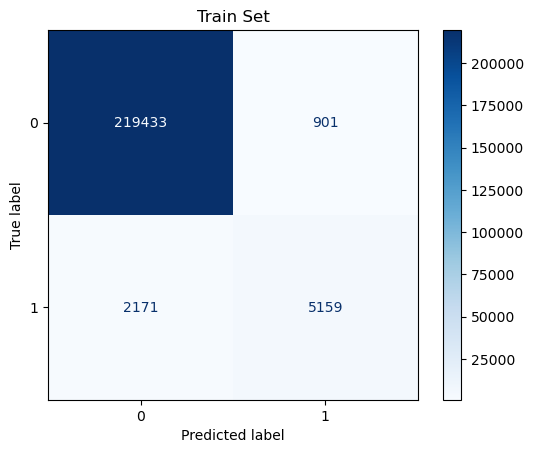


🔹 Test Set
Accuracy: 0.9860
F1 macro: 0.8777
F1 weighted: 0.9853
              precision    recall  f1-score   support

           0     0.9897    0.9958    0.9928     55066
           1     0.8479    0.6930    0.7626      1850

    accuracy                         0.9860     56916
   macro avg     0.9188    0.8444    0.8777     56916
weighted avg     0.9851    0.9860    0.9853     56916



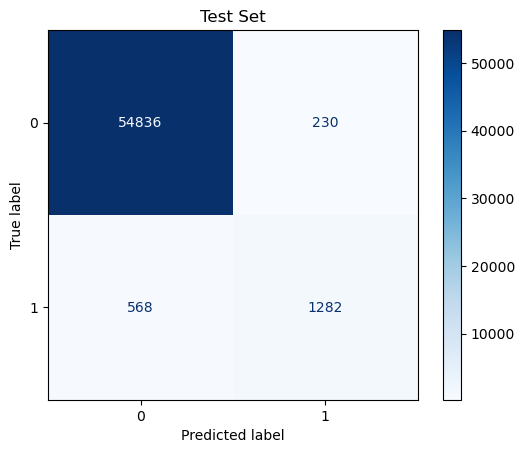


🔹 Global Set
Accuracy: 0.9864
F1 macro: 0.8810
F1 weighted: 0.9858
              precision    recall  f1-score   support

           0     0.9901    0.9959    0.9930    275400
           1     0.8506    0.7016    0.7690      9180

    accuracy                         0.9864    284580
   macro avg     0.9204    0.8488    0.8810    284580
weighted avg     0.9856    0.9864    0.9858    284580



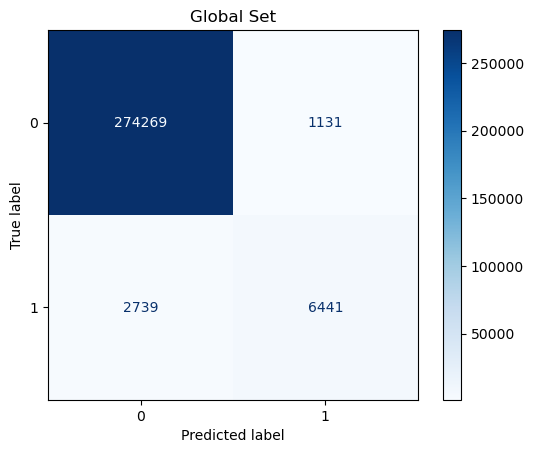


🎯 Résumé F1:
F1 Score Train Set : 0.8818
F1 Score Test Set  : 0.8777


In [ ]:
import lightgbm as lgb
import optuna


lgb_model = lgb.LGBMClassifier(random_state=42)

# Étape 2 : Optuna avec espace de recherche étendu
def objective(trial):
    param = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500, step=20),
        "max_depth": trial.suggest_int("max_depth", 2, 12),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 5.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 5.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 20),
        "random_state": 42,
        "boosting_type": "gbdt",
        "objective": "binary" if len(np.unique(Y_train)) == 2 else "multiclass",
        "metric": "multi_logloss" if len(np.unique(Y_train)) > 2 else "binary_logloss",
        "verbosity": -1
    }
    if len(np.unique(Y_train)) > 2:
        param["num_class"] = len(np.unique(Y_train))

    model = lgb.LGBMClassifier(**param)
    model.fit(
        X_train,
        Y_train,
        eval_set=[(X_test, Y_test)],
        eval_metric="logloss",
    )
    preds = model.predict(X_test)
    return f1_score(Y_test, preds, average="macro")

print("\n🎯 Début de l'optimisation Optuna (LightGBM)...")
study = optuna.create_study(direction="maximize")
with tqdm(total=50, desc="Optuna Trials") as pbar:
    def tqdm_callback(study, trial):
        pbar.update(1)
    study.optimize(objective, n_trials=50, callbacks=[tqdm_callback])

print("✅ Optuna terminé!")
print("Meilleurs paramètres Optuna:", study.best_params)

# Étape 3 : Modèle final avec les meilleurs hyperparamètres
final_params = dict(study.best_params)
final_params.update({
    "random_state": 42,
    "boosting_type": "gbdt",
    "objective": "binary" if len(np.unique(Y_train)) == 2 else "multiclass",
    "metric": "multi_logloss" if len(np.unique(Y_train)) > 2 else "binary_logloss",
    "verbosity": -1
})

if len(np.unique(Y_train)) > 2:
    final_params["num_class"] = len(np.unique(Y_train))

final_model = lgb.LGBMClassifier(**final_params)
final_model.fit(X_train, Y_train)

# Étape 4 : Évaluation
print("\n📊 Évaluation du modèle final")
y_train_pred = final_model.predict(X_train)
y_test_pred = final_model.predict(X_test)
y_global_true = np.concatenate([Y_train, Y_test])
y_global_pred = np.concatenate([y_train_pred, y_test_pred])

def display_metrics(y_true, y_pred, title):
    accuracy = np.mean(y_true == y_pred)
    f1_macro = f1_score(y_true, y_pred, average="macro")
    f1_weighted = f1_score(y_true, y_pred, average="weighted")
    print(f"\n🔹 {title}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1 macro: {f1_macro:.4f}")
    print(f"F1 weighted: {f1_weighted:.4f}")
    print(classification_report(y_true, y_pred, digits=4))
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues")
    plt.title(title)
    plt.show()

# Résultats
display_metrics(Y_train, y_train_pred, "Train Set")
display_metrics(Y_test, y_test_pred, "Test Set")
display_metrics(y_global_true, y_global_pred, "Global Set")

# Résumé F1
print("\n🎯 Résumé F1:")
print(f"F1 Score Train Set : {f1_score(Y_train, y_train_pred, average='macro'):.4f}")
print(f"F1 Score Test Set  : {f1_score(Y_test, y_test_pred, average='macro'):.4f}")
